# Assignment 2
## Build a Text Preprocessing Pipeline

### Name : Yogesh Pawar

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt

# Part 1 - Collect Data (wikipedia Scraping)

In [2]:

BASE_URL = "https://en.wikipedia.org/wiki/"

categories = {
    "AI": [
        "Artificial_intelligence",
        "Machine_learning",
        "Deep_learning",
        "Neural_network",
        "Natural_language_processing",
        "Computer_vision",
        "Expert_system",
        "Generative_artificial_intelligence",
        "Data_science",
        "Robotics",
        "Reinforcement_learning",
        "Artificial_neural_network",
        "Speech_recognition",
        "Large_language_model",
        "Predictive_analytics"
    ],

    "Climate": [
        "Climate_change",
        "Global_warming",
        "Greenhouse_gas",
        "Renewable_energy",
        "Carbon_dioxide",
        "Fossil_fuel",
        "Deforestation",
        "Carbon_footprint",
        "Solar_energy",
        "Wind_power",
        "Sustainability",
        "Sea_level_rise",
        "Paris_Agreement",
        "Methane_emissions",
        "Environmentalism"
    ],

    "Space": [
        "Space_exploration",
        "NASA",
        "Mars_rover",
        "Apollo_11",
        "International_Space_Station",
        "Moon_landing",
        "Mars",
        "Space_Shuttle",
        "Sputnik_1",
        "Hubble_Space_Telescope",
        "SpaceX",
        "Voyager_program",
        "Black_hole",
        "Astronomy",
        "Satellite"
    ],

    "History": [
        "World_War_II",
        "French_Revolution",
        "Roman_Empire",
        "Ancient_Egypt",
        "Industrial_Revolution",
        "Cold_War",
        "American_Civil_War",
        "Renaissance",
        "Mughal_Empire",
        "Ottoman_Empire",
        "Greek_civilization",
        "Medieval_history",
        "Russian_Revolution",
        "History_of_China",
        "History_of_India"
    ]
}

dataset = []

headers = {"User-Agent": "Mozilla/5.0"}

for label, articles in categories.items():
    for article in articles:
        url = BASE_URL + article
        try:
            print(f"Scraping: {article}")
            response = requests.get(url, headers=headers)
            soup = BeautifulSoup(response.text, "html.parser")
            content_div = soup.find("div", {"id": "mw-content-text"})
            paragraphs = content_div.find_all("p")
            article_text = ""
            for p in paragraphs:
                text = p.get_text(strip=True)
                if len(text) > 50:
                    article_text += text + " "
            article_text = article_text.replace("\n", " ")

            dataset.append({
                "Text": article_text,
                "Label": label
            })

            time.sleep(1)

        except Exception as e:
            print(f"Error scraping {article}: {e}")

Scraping: Artificial_intelligence
Scraping: Machine_learning
Scraping: Deep_learning
Scraping: Neural_network
Scraping: Natural_language_processing
Scraping: Computer_vision
Scraping: Expert_system
Scraping: Generative_artificial_intelligence
Scraping: Data_science
Scraping: Robotics
Scraping: Reinforcement_learning
Scraping: Artificial_neural_network
Scraping: Speech_recognition
Scraping: Large_language_model
Scraping: Predictive_analytics
Scraping: Climate_change
Scraping: Global_warming
Scraping: Greenhouse_gas
Scraping: Renewable_energy
Scraping: Carbon_dioxide
Scraping: Fossil_fuel
Scraping: Deforestation
Scraping: Carbon_footprint
Scraping: Solar_energy
Scraping: Wind_power
Scraping: Sustainability
Scraping: Sea_level_rise
Scraping: Paris_Agreement
Scraping: Methane_emissions
Scraping: Environmentalism
Scraping: Space_exploration
Scraping: NASA
Scraping: Mars_rover
Scraping: Apollo_11
Scraping: International_Space_Station
Scraping: Moon_landing
Scraping: Mars
Scraping: Space_Shut

In [3]:
# Load Dataset
df = pd.DataFrame(dataset)
print(f"Total articles scraped: {len(df)}")

Total articles scraped: 60


In [4]:
df.head()


,Text,Label
0,Artificial intelligence(AI) is the capability ...,AI
1,Machine learning(ML) is a field of study inart...,AI
2,"Inmachine learning,deep learning(DL) focuses o...",AI
3,Aneural networkis a group of interconnected un...,AI
4,Natural language processing(NLP) is the proces...,AI


In [5]:
# Save to CSV
df.to_csv("raw_dataset.csv", index=False)

print("File saved as raw_dataset.csv")

File saved as raw_dataset.csv


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    60 non-null     object
 1   Label   60 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


In [7]:
# Check for missing values
df.isnull().sum()

Text     0
Label    0
dtype: int64

In [8]:
# Count samples per class
class_counts = df['Label'].value_counts()
print(class_counts)

Label
AI         15
Climate    15
Space      15
History    15
Name: count, dtype: int64


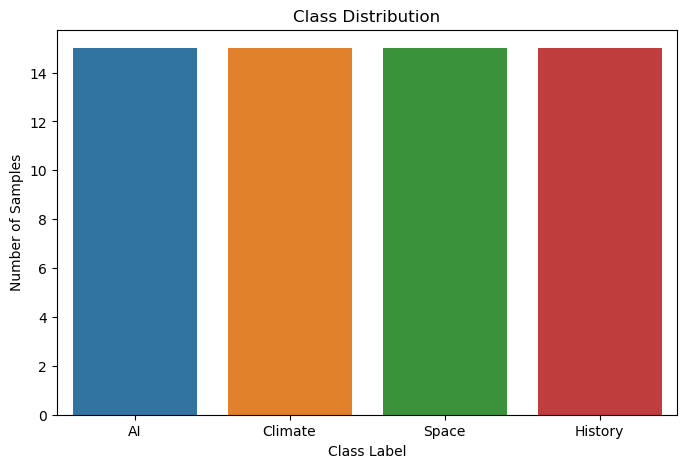

In [9]:
# Plot 
plt.figure(figsize=(8, 5))
sns.barplot(x = class_counts.index, y=class_counts.values,hue=class_counts.index,legend=False)
plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

In [10]:
# Text preprocessing libraries
import re
import nltk
import wordninja
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ravikant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ravikant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ravikant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ravikant\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ravikant\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Part 2 - Clean the Text

In [11]:

def clean_text(text):
    text = str(text)

    # Step 1: remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Step 2: remove citations like [1], [23]
    text = re.sub(r"\[\d+\]", " ", text)

    # Step 3: remove punctuation
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Step 4: lowercase
    text = text.lower()

    # Step 5: word segmentation (wordninja)
    text = " ".join(
        " ".join(wordninja.split(w)) if len(w) > 2 else w
        for w in text.split()
    )

    # Step 6: remove extra spaces
    text = " ".join(text.split())

    return text


# Apply once, correctly
df["clean_Text"] = df["Text"].apply(clean_text)

print("Before:\n", df["Text"].head())
print("\nAfter:\n", df["clean_Text"].head())

Before:
 0    Artificial intelligence(AI) is the capability ...
1    Machine learning(ML) is a field of study inart...
2    Inmachine learning,deep learning(DL) focuses o...
3    Aneural networkis a group of interconnected un...
4    Natural language processing(NLP) is the proces...
Name: Text, dtype: object

After:
 0    artificial intelligence ai is the capability o...
1    machine learning ml is a field of study in art...
2    in machine learning deep learning dl focuses o...
3    a neural network is a group of interconnected ...
4    natural language processing nlp is the process...
Name: clean_Text, dtype: object


In [12]:
df.head()

,Text,Label,clean_Text
0,Artificial intelligence(AI) is the capability ...,AI,artificial intelligence ai is the capability o...
1,Machine learning(ML) is a field of study inart...,AI,machine learning ml is a field of study in art...
2,"Inmachine learning,deep learning(DL) focuses o...",AI,in machine learning deep learning dl focuses o...
3,Aneural networkis a group of interconnected un...,AI,a neural network is a group of interconnected ...
4,Natural language processing(NLP) is the proces...,AI,natural language processing nlp is the process...


In [13]:
# Save to CSV
df.to_csv("clean_dataset.csv", index=False)

print("File saved as cleaned_dataset.csv")

File saved as cleaned_dataset.csv


# Part 3 -  NLP Preprocessing


In [14]:
# step1 : Tokenisation
tokens = nltk.word_tokenize(df["clean_Text"][0])
print(tokens[:20])

['artificial', 'intelligence', 'ai', 'is', 'the', 'capability', 'of', 'computational', 'systems', 'to', 'perform', 'tasks', 'typically', 'associated', 'with', 'human', 'intelligence', 'such', 'as', 'learning']


In [15]:
# step 2: Remove stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))

total_removed = 0

for doc in df["clean_Text"]:
    tokens = word_tokenize(doc.lower())

    # Count stopwords removed
    removed = [word for word in  tokens if word in stop_words]
    filtered = [word for word in tokens if word.isalpha() not in stop_words]
    total_removed += len(removed)
  
    print(f"Document: {doc[:200]}")
    print(f"Stopwords removed: {removed[:20]}")
    print(f"Filtered tokens: {filtered[:20]}")
    print(f"Number removed: {len(removed)}\n")


Document: artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem solving perception and decision m
Stopwords removed: ['is', 'the', 'of', 'to', 'with', 'such', 'as', 'and', 'it', 'is', 'a', 'of', 'in', 'and', 'that', 'and', 'and', 'that', 'to', 'their']
Filtered tokens: ['artificial', 'intelligence', 'ai', 'is', 'the', 'capability', 'of', 'computational', 'systems', 'to', 'perform', 'tasks', 'typically', 'associated', 'with', 'human', 'intelligence', 'such', 'as', 'learning']
Number removed: 5136

Document: machine learning ml is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data and thus pe
Stopwords removed: ['is', 'a', 'of', 'in', 'with', 'the', 'and', 'of', 'that', 'can', 'from', 'and', 'to', 'and', 'being', 'in', 'the', 'of', 'have', 'a']
Filtered tokens: ['

In [16]:
# Step 3: Stemming vs Lemmatization

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
tokens = filtered
# Apply stemming
tokens_stemmed = [stemmer.stem(token) for token in tokens]

# Apply lemmatization
tokens_lemmatized = [lemmatizer.lemmatize(token) for token in tokens]

# Display comparison
print("Original Words       | Stemmed    | Lemmatized")
print("-" * 45)

for w, s, l in list(zip(tokens, tokens_stemmed, tokens_lemmatized))[:10]:
    print(f"{w:<20} | {s:<10} | {l}")

Original Words       | Stemmed    | Lemmatized
---------------------------------------------
anatomically         | anatom     | anatomically
modern               | modern     | modern
humans               | human      | human
are                  | are        | are
estimated            | estim      | estimated
to                   | to         | to
have                 | have       | have
first                | first      | first
arrived              | arriv      | arrived
on                   | on         | on


Which is better and why?

Lemmatization is better in most NLP tasks
It Produces valid dictionary words
Preserves meaning and context
Better for tasks like:
Text classification


# Part 4 — Convert Text to Numbers (TF-IDF)


In [18]:
# Select target variable
y = df["Label"]

In [19]:
# Select input variables
X = df["clean_Text"]

In [20]:
# Split in train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english',max_features=5000)

# Transform text into TF-IDF representation
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

# Display results
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nX_train TF-IDF Matrix:\n", X_train_tfidf.toarray())
print("\nX_test TF-IDF Matrix:\n", X_test_tfidf.toarray())

Vocabulary: ['000' '05' '10' ... 'zon' 'zones' 'zvezda']

X_train TF-IDF Matrix:
 [[0.01039601 0.         0.00261676 ... 0.         0.00293078 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.00194433 ... 0.         0.         0.        ]
 ...
 [0.00509993 0.00503209 0.         ... 0.         0.         0.        ]
 [0.06854452 0.         0.01045147 ... 0.         0.         0.        ]
 [0.03737088 0.         0.01646147 ... 0.         0.         0.        ]]

X_test TF-IDF Matrix:
 [[0.00383948 0.         0.0033825  ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.0185086  0.00365248 0.00978341 ... 0.         0.         0.        ]
 ...
 [0.07223399 0.         0.00830043 ... 0.         0.         0.        ]
 [0.07342811 0.         0.03483232 ... 0.         0.         0.        ]
 [0.01904351 0.         0.00699038 ... 0.         0.0062634  0.        ]]


In [22]:
# Top 15 important words per category
feature_names = np.array(vectorizer.get_feature_names_out())
for category in np.unique(y_train):
    idx = np.where(np.array(y_train) == category)[0]

    mean_scores = np.asarray(X_train_tfidf[idx].mean(axis=0)).flatten()

    top_idx = mean_scores.argsort()[-15:][::-1]

    print(f"\nCategory: {category}")
    print(feature_names[top_idx])


Category: AI
['learning' 'neural' 'data' 'ai' 'networks' 'machine' 'robots' 'models'
 'generative' 'expert' 'deep' 'neurons' 'nlp' 'training' 'network']

Category: Climate
['climate' 'carbon' 'emissions' 'energy' 'fossil' 'greenhouse' 'methane'
 'solar' 'global' 'change' 'dioxide' 'gas' 'wind' 'warming'
 'environmental']

Category: History
['empire' 'greek' 'roman' 'mughal' 'th' 'dynasty' 'renaissance' 'century'
 'emperor' 'war' 'india' 'western' 'europe' 'indian' 'period']

Category: Space
['space' 'nasa' 'launch' 'mission' 'spacecraft' 'satellite' 'orbit' 'mars'
 'satellites' 'earth' 'voyager' 'moon' 'landing' 'shuttle' 'station']


In [23]:
# Shape of TF-IDF
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (48, 5000)
Test TF-IDF shape: (12, 5000)


In [24]:
# Covert it in dataframe
X_train_tfidf = pd.DataFrame(X_train_tfidf.toarray(),columns = vectorizer.get_feature_names_out())

In [25]:
X_train_tfidf.head()

,000,05,10,100,1000,101,104,109,11,110,...,za,zed,zenith,zero,zhang,zhou,zhu,zon,zones,zvezda
0,0.010396,0.0,0.002617,0.002907,0.0,0.0,0.0,0.0,0.011607,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002931,0.0
1,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.000000,0.0,0.001944,0.000000,0.0,0.0,0.0,0.0,0.004928,0.0,...,0.010021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.005211,0.0,0.013772,0.005100,0.0,0.0,0.0,0.0,0.005818,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [26]:
# convert it into dataframe
X_test_tfidf= pd.DataFrame(X_test_tfidf.toarray(),columns = vectorizer.get_feature_names_out())

In [27]:
X_test_tfidf.head()

,000,05,10,100,1000,101,104,109,11,110,...,za,zed,zenith,zero,zhang,zhou,zhu,zon,zones,zvezda
0,0.003839,0.000000,0.003383,0.003758,0.000000,0.000000,0.0,0.0,0.002143,0.00000,...,0.004358,0.000000,0.0,0.002532,0.0,0.000000,0.0,0.0,0.000000,0.0
1,0.000000,0.000000,0.000000,0.000000,0.007631,0.000000,0.0,0.0,0.000000,0.00000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2,0.018509,0.003652,0.009783,0.014493,0.000000,0.003812,0.0,0.0,0.008266,0.00351,...,0.000000,0.000000,0.0,0.004882,0.0,0.000000,0.0,0.0,0.000000,0.0
3,0.033697,0.000000,0.009896,0.004712,0.000000,0.000000,0.0,0.0,0.005375,0.00000,...,0.003643,0.000000,0.0,0.000000,0.0,0.004934,0.0,0.0,0.018999,0.0
4,0.005523,0.005450,0.000000,0.002703,0.000000,0.000000,0.0,0.0,0.006167,0.00000,...,0.000000,0.005044,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0


# Part 5 - Save and Explain

In [31]:
df.head()

,Text,Label,clean_Text
0,Artificial intelligence(AI) is the capability ...,AI,artificial intelligence ai is the capability o...
1,Machine learning(ML) is a field of study inart...,AI,machine learning ml is a field of study in art...
2,"Inmachine learning,deep learning(DL) focuses o...",AI,in machine learning deep learning dl focuses o...
3,Aneural networkis a group of interconnected un...,AI,a neural network is a group of interconnected ...
4,Natural language processing(NLP) is the proces...,AI,natural language processing nlp is the process...


In [32]:
df.to_csv("final_dataset.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


Project: Wikipedia Text Preprocessing Pipeline

In this project, I developed a complete NLP preprocessing pipeline using Wikipedia articles from four domains: Artificial Intelligence, Climate Change, Space Exploration, and Famous Scientists. The objective was to transform raw textual data into a machine-learning-ready format while understanding each preprocessing stage and its impact on the dataset.

The project began with automated data collection using web scraping techniques. A total of 60 articles were collected and stored with category labels. The raw text was then cleaned by removing citations, punctuation, extra spaces, and converting all text to lowercase. After cleaning, tokenization was applied to split text into individual words. Stopword removal reduced noise by eliminating common words that contributed little semantic value.

To compare normalization techniques, both stemming and lemmatization were implemented. While stemming produced shorter word roots, lemmatization generated more meaningful dictionary words, making it more suitable for downstream NLP tasks. The processed tokens were then joined to create a final clean text column.

Finally, TF-IDF vectorization was used to convert text into numerical features. This enabled identification of the most important terms within each category and prepared the dataset for future machine learning applications such as text classification.

One interesting insight was that Space Exploration articles consistently contained highly specialized vocabulary, resulting in distinct TF-IDF features. A surprising learning experience was observing how aggressively stemming can distort words compared to lemmatization, even though both aim to reduce word variations.

This project strengthened my understanding of end-to-end text preprocessing workflows in Natural Language Processing